In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Añadimos la raíz para importar nuestros módulos y definimos rutas
sys.path.append('..')
from src.data_preprocessing import load_gym_data

# Configuración visual para gráficos más profesionales
sns.set_theme(style="whitegrid")
PLOTS_DIR = '../results/plots/'
os.makedirs(PLOTS_DIR, exist_ok=True)

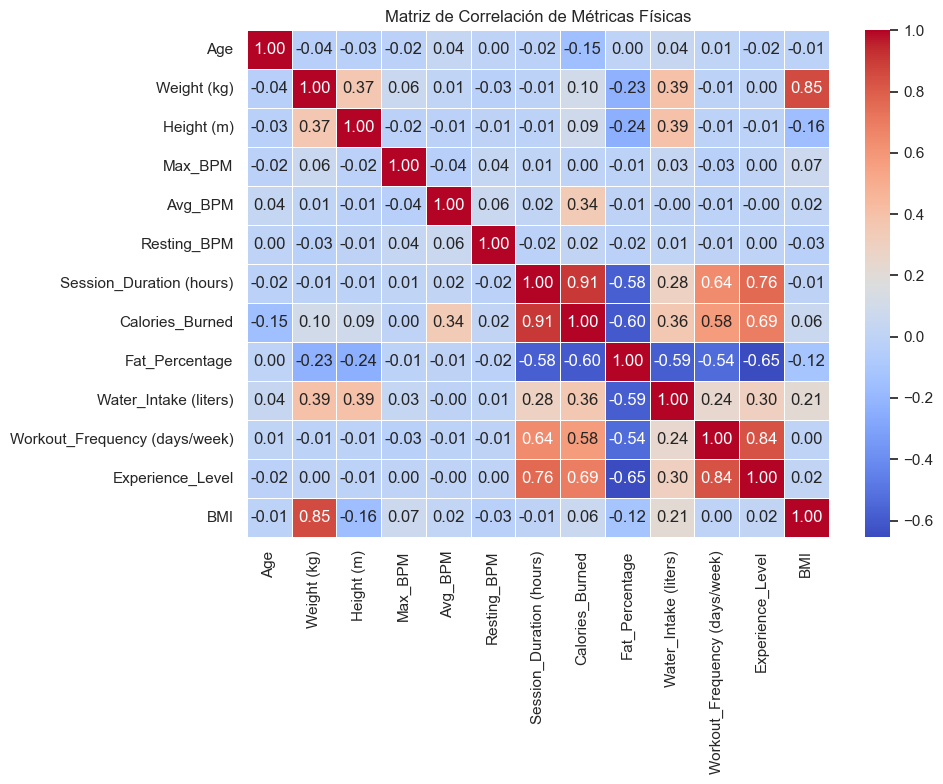

In [2]:
# Cargar el dataset usando nuestra función modular
df = load_gym_data('../data/gym_members_exercise_tracking.csv')

# Visualizar la matriz de correlación para entender las relaciones lineales
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = df[numeric_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de Métricas Físicas')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '01_correlation_matrix.png'))
plt.show()

Varianza explicada por PCA1: 0.49
Varianza explicada por PCA2: 0.26


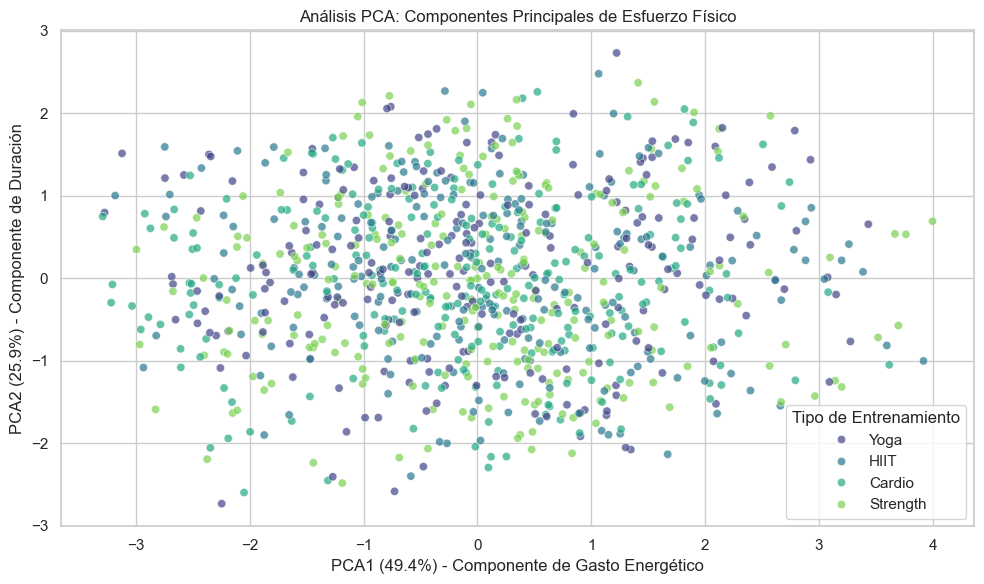

In [3]:
# Seleccionamos métricas de esfuerzo e intensidad
esfuerzo_cols = ['Max_BPM', 'Avg_BPM', 'Session_Duration (hours)', 'Calories_Burned']
X_esfuerzo = df[esfuerzo_cols]

# Escalamos los datos (vital para PCA y K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_esfuerzo)

# Aplicamos PCA para reducir a 2 componentes
pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(X_scaled)

df['PCA1'] = pca_components[:, 0]
df['PCA2'] = pca_components[:, 1]

# Varianza explicada
var_exp = pca.explained_variance_ratio_
print(f"Varianza explicada por PCA1: {var_exp[0]:.2f}")
print(f"Varianza explicada por PCA2: {var_exp[1]:.2f}")

# Graficamos el resultado del PCA coloreando por tipo de entrenamiento
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Workout_Type', data=df, palette='viridis', alpha=0.7)
plt.title('Análisis PCA: Componentes Principales de Esfuerzo Físico')
plt.xlabel(f'PCA1 ({var_exp[0]*100:.1f}%) - Componente de Gasto Energético')
plt.ylabel(f'PCA2 ({var_exp[1]*100:.1f}%) - Componente de Duración')
plt.legend(title='Tipo de Entrenamiento')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '02_pca_esfuerzo.png'))
plt.show()

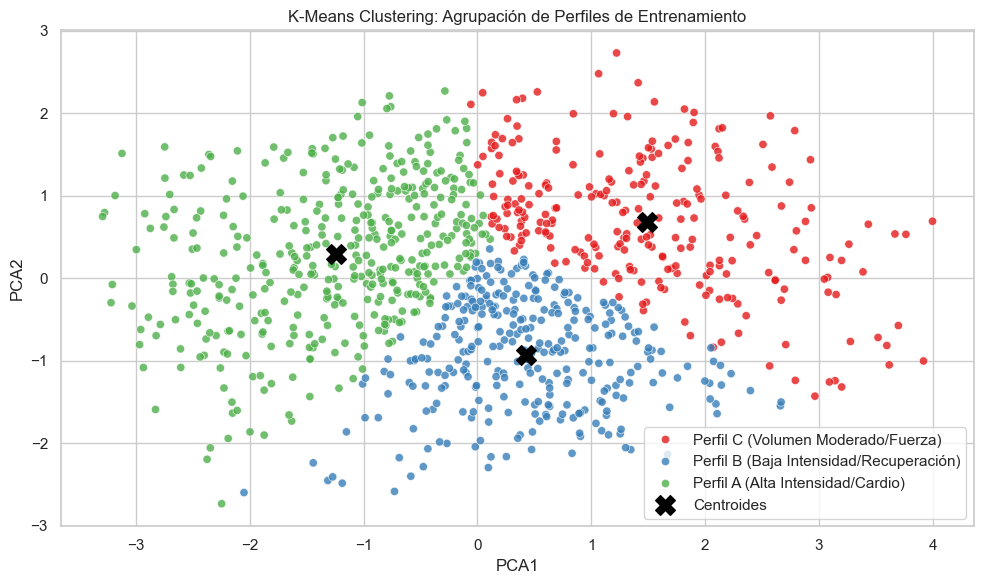

,Max_BPM,Avg_BPM,Session_Duration (hours),Calories_Burned
Cluster_Name,,,,
Perfil A (Alta Intensidad/Cardio),182.29,136.40,0.99,670.23
Perfil B (Baja Intensidad/Recuperación),172.04,153.90,1.29,980.80
Perfil C (Volumen Moderado/Fuerza),185.80,143.09,1.65,1195.52


In [4]:
# Entrenamos K-Means sobre las componentes del PCA
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(pca_components)

# Etiquetas descriptivas basadas en la intuición de los datos
cluster_labels = {
    0: 'Perfil A (Alta Intensidad/Cardio)',
    1: 'Perfil B (Baja Intensidad/Recuperación)',
    2: 'Perfil C (Volumen Moderado/Fuerza)'
}
df['Cluster_Name'] = df['Cluster'].map(cluster_labels)

# Visualización de los Clústeres
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster_Name', data=df, palette='Set1', alpha=0.8)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            s=200, c='black', marker='X', label='Centroides')

plt.title('K-Means Clustering: Agrupación de Perfiles de Entrenamiento')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '03_kmeans_clusters.png'))
plt.show()

# Resumen de los clústeres para argumentar en la presentación
cluster_summary = df.groupby('Cluster_Name')[esfuerzo_cols].mean().round(2)
display(cluster_summary)